# Comparator-Based Relaxation Oscillator

A relaxation oscillator using a TLV3201-style comparator with Schmitt trigger feedback.

**Circuit topology:**
- R2/R3 (20k each) form a voltage divider setting the midpoint reference at V+/2 = 2.5V
- R4 (20k) provides positive feedback from output to non-inverting input (Schmitt trigger hysteresis)
- R1 (6.8k) and C1 (100pF) form the RC timing network at the inverting input
- The comparator output switches rail-to-rail (0V to 5V)

**Operation:**
1. When Vo = HIGH (5V): R4 pulls inp above Vc threshold. C1 charges through R1 toward 5V.
2. When Vc rises above inp: comparator switches to LOW (0V).
3. When Vo = LOW (0V): R4 pulls inp below Vc threshold. C1 discharges through R1 toward 0V.
4. When Vc falls below inp: comparator switches to HIGH. Cycle repeats.

## Circuit Schematic

![Relaxation Oscillator Schematic](relaxation_oscillator_schematic.svg)

In [1]:
import neospice as ns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 100

## Circuit Definition

The TLV3201 comparator is modeled as a behavioral voltage source with a `tanh` transfer
function, giving rail-to-rail output (0V to 5V) with a sharp but continuous transition.

| Component | Value | Role |
|-----------|-------|------|
| Vcc | 5V | Supply voltage |
| R2 | 20kΩ | Upper divider resistor |
| R3 | 20kΩ | Lower divider resistor |
| R4 | 20kΩ | Positive feedback (hysteresis) |
| R1 | 6.8kΩ | Timing resistor |
| C1 | 100pF | Timing capacitor |

The circuit is constructed using neospice's Python circuit builder API.

In [ ]:
sim = ns.Simulator()
ckt = ns.Circuit()

# 5V supply
ckt.V("Vcc", "vcc", "0", dc=5.0)

# Voltage divider + positive feedback network
# R2/R3 set midpoint at 2.5V, R4 adds hysteresis from output
R2, R3, R4 = 20e3, 20e3, 20e3
ckt.R("R2", "vcc", "inp", R2)
ckt.R("R3", "inp", "0", R3)
ckt.R("R4", "inp", "vo", R4)

# RC timing network at inverting input
ckt.R("R1", "vo", "vc", 6.8e3)
ckt.C("C1", "vc", "0", 100e-12, ic=0.0)

# Comparator: behavioral model with tanh transfer function
# Output swings 0V to 5V, gain=100 gives ~50mV input resolution
ckt.B("Bcomp", "vo", "0", expr="V={2.5+2.5*tanh(100*(V(inp)-V(vc)))}")

# Calculate expected thresholds
Vcc = 5.0
Vth_high = (Vcc/R2 + Vcc/R4) / (1/R2 + 1/R3 + 1/R4)  # Vo=5V
Vth_low = (Vcc/R2 + 0/R4) / (1/R2 + 1/R3 + 1/R4)     # Vo=0V
print(f"Upper threshold (Vo=HIGH): {Vth_high:.3f}V")
print(f"Lower threshold (Vo=LOW):  {Vth_low:.3f}V")
print(f"Hysteresis: {Vth_high - Vth_low:.3f}V")
print(f"RC time constant: {6.8e3 * 100e-12 * 1e9:.1f} ns")

## Run Transient Simulation

In [ ]:
# Relaxed convergence settings needed for the switching transitions
ckt.options.reltol = 0.005
ckt.options.abstol = 1e-10
ckt.options.vntol = 1e-4
ckt.options.gmin = 1e-9
ckt.options.itl4 = 500

topts = ns.TransientOptions()
topts.uic = True

tran = sim.run_transient_with_opts(ckt, 0.5e-9, 10e-6, topts)

print(f"Simulation converged: {tran.status.converged}")
print(f"Time points: {len(tran.time)}")
print(f"Available signals: {tran.signal_names()}")

## Extract Waveforms

In [4]:
time = tran.time
vo = tran.voltage('vo')       # comparator output
vc = tran.voltage('vc')       # capacitor voltage (inverting input)
vinp = tran.voltage('inp')    # non-inverting input (reference + feedback)

print(f"Vo range:  {vo.min():.3f}V to {vo.max():.3f}V")
print(f"Vc range:  {vc.min():.3f}V to {vc.max():.3f}V")
print(f"Vinp range: {vinp.min():.3f}V to {vinp.max():.3f}V")

Vo range:  -0.000V to 5.000V
Vc range:  0.004V to 3.299V
Vinp range: 1.667V to 3.333V


## Plot Output Waveforms

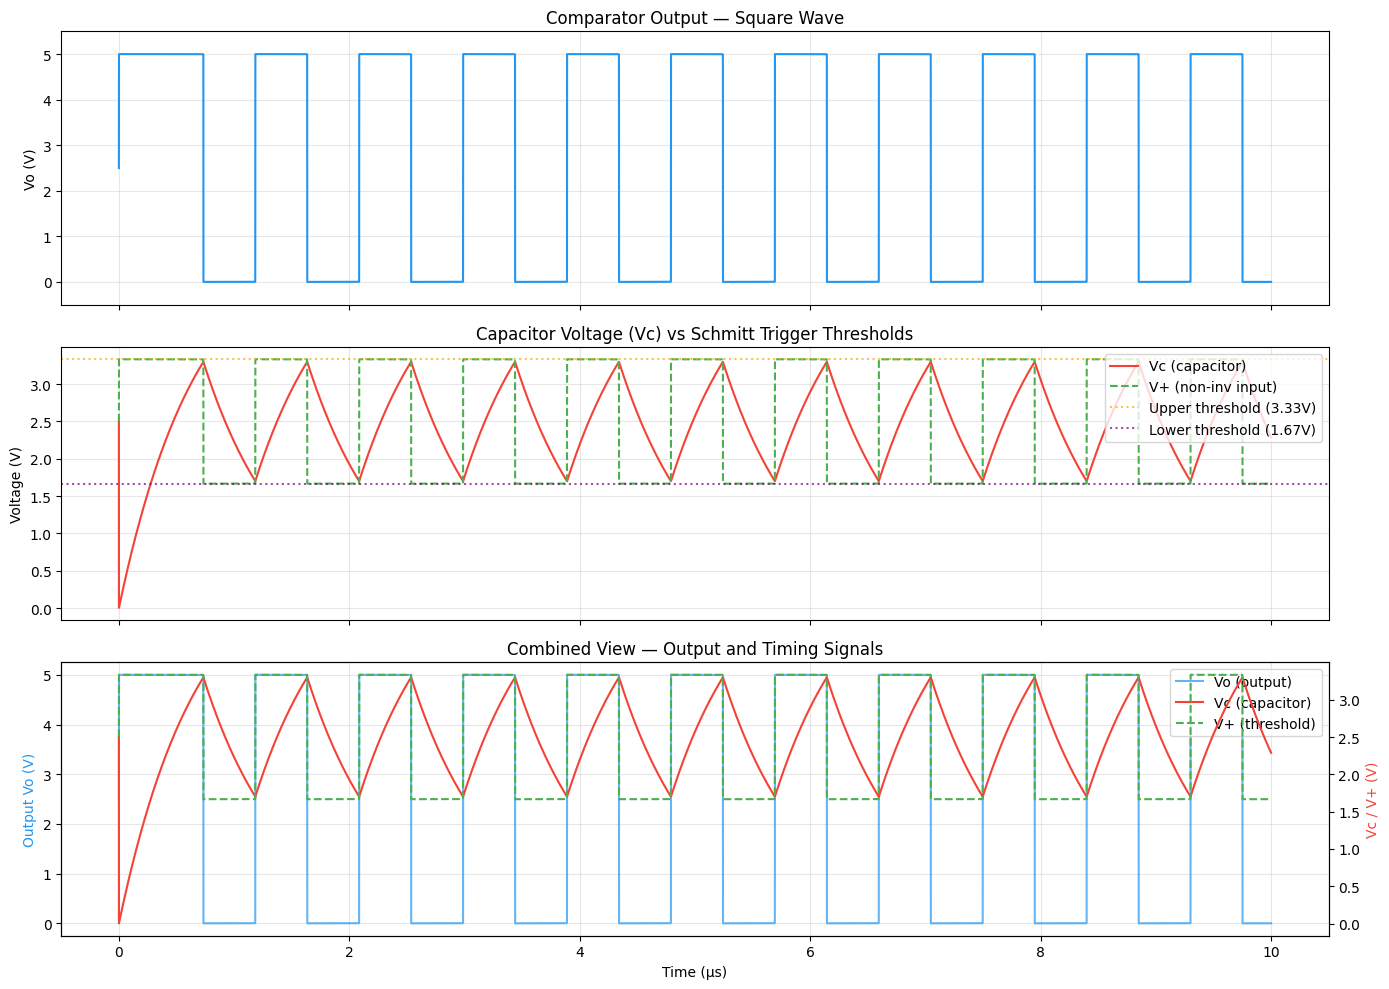

Waveforms saved to relaxation_oscillator_waveforms.png


In [5]:
t_us = time * 1e6  # convert to microseconds

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(14, 10))

# Comparator output
axes[0].plot(t_us, vo, color='#2196F3', linewidth=1.5)
axes[0].set_ylabel('Vo (V)')
axes[0].set_title('Comparator Output — Square Wave')
axes[0].set_ylim(-0.5, 5.5)
axes[0].grid(True, alpha=0.3)

# Capacitor voltage vs thresholds
axes[1].plot(t_us, vc, color='#F44336', linewidth=1.5, label='Vc (capacitor)')
axes[1].plot(t_us, vinp, color='#4CAF50', linewidth=1.5, label='V+ (non-inv input)', linestyle='--')
axes[1].axhline(y=Vth_high, color='orange', linestyle=':', alpha=0.7, label=f'Upper threshold ({Vth_high:.2f}V)')
axes[1].axhline(y=Vth_low, color='purple', linestyle=':', alpha=0.7, label=f'Lower threshold ({Vth_low:.2f}V)')
axes[1].set_ylabel('Voltage (V)')
axes[1].set_title('Capacitor Voltage (Vc) vs Schmitt Trigger Thresholds')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Combined view: output and capacitor overlaid
ax3a = axes[2]
ax3b = ax3a.twinx()
p1, = ax3a.plot(t_us, vo, color='#2196F3', linewidth=1.5, alpha=0.7, label='Vo (output)')
p2, = ax3b.plot(t_us, vc, color='#F44336', linewidth=1.5, label='Vc (capacitor)')
p3, = ax3b.plot(t_us, vinp, color='#4CAF50', linewidth=1.5, linestyle='--', label='V+ (threshold)')
ax3a.set_ylabel('Output Vo (V)', color='#2196F3')
ax3b.set_ylabel('Vc / V+ (V)', color='#F44336')
ax3a.set_xlabel('Time (μs)')
axes[2].set_title('Combined View — Output and Timing Signals')
lines = [p1, p2, p3]
ax3a.legend(lines, [l.get_label() for l in lines], loc='upper right')
ax3a.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('relaxation_oscillator_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waveforms saved to relaxation_oscillator_waveforms.png")

## Measure Oscillation Parameters

In [6]:
threshold = 2.5
rising_edges = []
falling_edges = []
for i in range(1, len(vo)):
    if vo[i-1] < threshold and vo[i] >= threshold:
        rising_edges.append(time[i])
    elif vo[i-1] > threshold and vo[i] <= threshold:
        falling_edges.append(time[i])

if len(rising_edges) >= 2:
    periods = np.diff(rising_edges)
    avg_period = np.mean(periods)
    freq = 1.0 / avg_period
    
    # Duty cycle: find first falling edge after the first rising edge
    later_falls = [f for f in falling_edges if f > rising_edges[0]]
    if later_falls:
        t_high = later_falls[0] - rising_edges[0]
        duty = t_high / avg_period * 100
    else:
        duty = float('nan')
    
    print(f"Number of complete cycles: {len(periods)}")
    print(f"Average period: {avg_period*1e9:.1f} ns")
    print(f"Frequency: {freq/1e6:.2f} MHz")
    print(f"Duty cycle: {duty:.1f}%")
    print(f"Vc swing: {vc.min():.3f}V to {vc.max():.3f}V")
    print(f"V+ swing: {vinp.min():.3f}V to {vinp.max():.3f}V")
else:
    print(f"Only {len(rising_edges)} rising edge(s) found.")

Number of complete cycles: 9
Average period: 901.9 ns
Frequency: 1.11 MHz
Duty cycle: 50.0%
Vc swing: 0.004V to 3.299V
V+ swing: 1.667V to 3.333V


## Detailed View: Two Oscillation Cycles

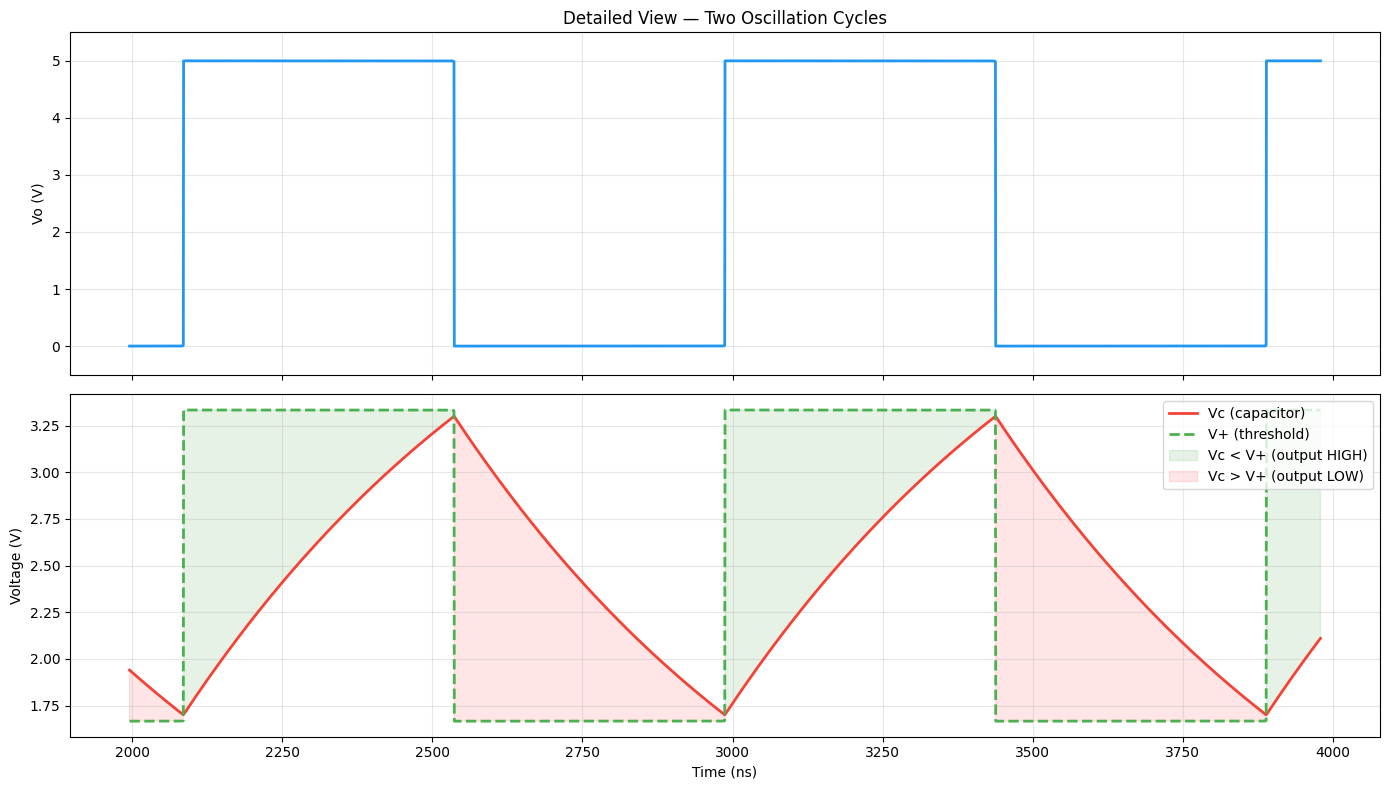

In [7]:
if len(rising_edges) >= 3:
    t_start = rising_edges[1] - 0.1 * avg_period
    t_end = rising_edges[3] + 0.1 * avg_period if len(rising_edges) > 3 else rising_edges[2] + 0.5 * avg_period
    mask = (time >= t_start) & (time <= t_end)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))
    
    ax1.plot(time[mask]*1e9, vo[mask], color='#2196F3', linewidth=2)
    ax1.set_ylabel('Vo (V)')
    ax1.set_title('Detailed View — Two Oscillation Cycles')
    ax1.set_ylim(-0.5, 5.5)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(time[mask]*1e9, vc[mask], color='#F44336', linewidth=2, label='Vc (capacitor)')
    ax2.plot(time[mask]*1e9, vinp[mask], color='#4CAF50', linewidth=2, linestyle='--', label='V+ (threshold)')
    ax2.fill_between(time[mask]*1e9, vc[mask], vinp[mask], 
                     where=vc[mask] < vinp[mask], alpha=0.1, color='green', label='Vc < V+ (output HIGH)')
    ax2.fill_between(time[mask]*1e9, vc[mask], vinp[mask],
                     where=vc[mask] >= vinp[mask], alpha=0.1, color='red', label='Vc > V+ (output LOW)')
    ax2.set_ylabel('Voltage (V)')
    ax2.set_xlabel('Time (ns)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()